# 02 — Price Exploration: ERCOT Hub LMP Analysis

**Goal:** Understand ERCOT price patterns, volatility, and arbitrage opportunities across the 4 settlement hubs. This sets the context for the dispatch optimizer in NB 03.

**Data:** Hourly RT and DA LMP prices from GCS pipeline (2010–2025). We focus on **2024–2025** for the backtest but show historical context.

**Key questions:**
1. Which hub has the most volatile prices (= best arbitrage)?
2. How big are daily price spreads?
3. When do negative prices occur?
4. What's the DA vs RT premium?

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

PRICES_DIR = os.path.join(os.pardir, 'data', 'prices')
HUBS = ['HB_HOUSTON', 'HB_NORTH', 'HB_SOUTH', 'HB_WEST']

# Load all RT and DA prices
rt_prices = {}
da_prices = {}
for hub in HUBS:
    rt = pd.read_parquet(os.path.join(PRICES_DIR, f'{hub}_rt_hourly.parquet'))
    da = pd.read_parquet(os.path.join(PRICES_DIR, f'{hub}_da_hourly.parquet'))
    rt_prices[hub] = rt['price']
    da_prices[hub] = da['price']

rt_df = pd.DataFrame(rt_prices)
da_df = pd.DataFrame(da_prices)

# Focus on 2024-2025 for backtest relevance
rt_recent = rt_df['2024':'2025']
da_recent = da_df['2024':'2025']

print(f"Full dataset: {rt_df.index.min().date()} to {rt_df.index.max().date()} ({len(rt_df):,} hours)")
print(f"Recent subset: {rt_recent.index.min().date()} to {rt_recent.index.max().date()} ({len(rt_recent):,} hours)")

Full dataset: 2010-12-01 to 2025-12-29 (132,169 hours)
Recent subset: 2024-01-01 to 2025-12-29 (17,479 hours)


## Summary Statistics by Hub (2024–2025 RT Prices)

In [2]:
stats = rt_recent.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
stats.columns = ['count', 'mean', 'std', 'min', 'P5', 'P25', 'median', 'P75', 'P95', 'max']
stats[['mean', 'std', 'min', 'P5', 'median', 'P95', 'max']].round(2)

,mean,std,min,P5,median,P95,max
HB_HOUSTON,29.97,55.15,-163.63,6.11,22.97,68.10,3066.05
HB_NORTH,28.48,61.27,-32.42,3.34,21.57,66.59,3048.16
HB_SOUTH,28.64,57.21,-100.90,3.74,21.97,66.73,3089.23
HB_WEST,29.63,63.36,-31.74,-2.34,22.63,75.22,3038.34


## RT Price Time Series (2024–2025)

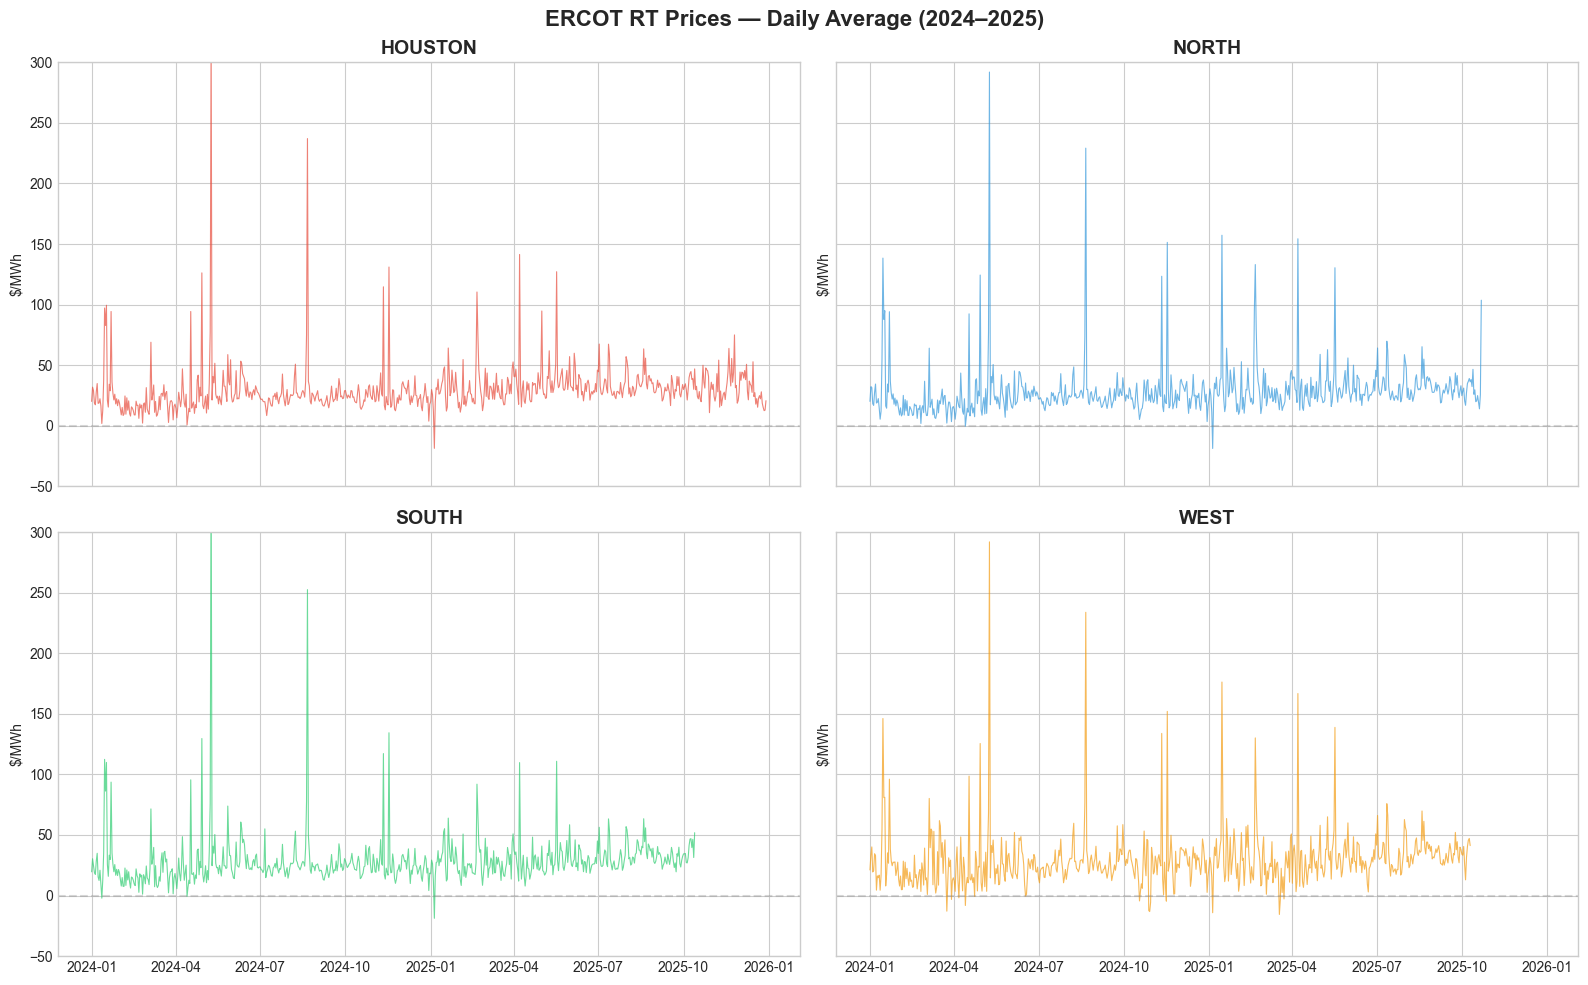

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, hub, color in zip(axes.flat, HUBS, colors):
    daily_avg = rt_recent[hub].resample('D').mean()
    ax.plot(daily_avg.index, daily_avg.values, color=color, alpha=0.7, linewidth=0.8)
    ax.set_title(hub.replace('HB_', ''), fontsize=14, fontweight='bold')
    ax.set_ylabel('$/MWh')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_ylim(-50, 300)

fig.suptitle('ERCOT RT Prices — Daily Average (2024–2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(os.pardir, 'data', 'results', 'price_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## Monthly Volatility (Std Dev of Hourly RT Prices)

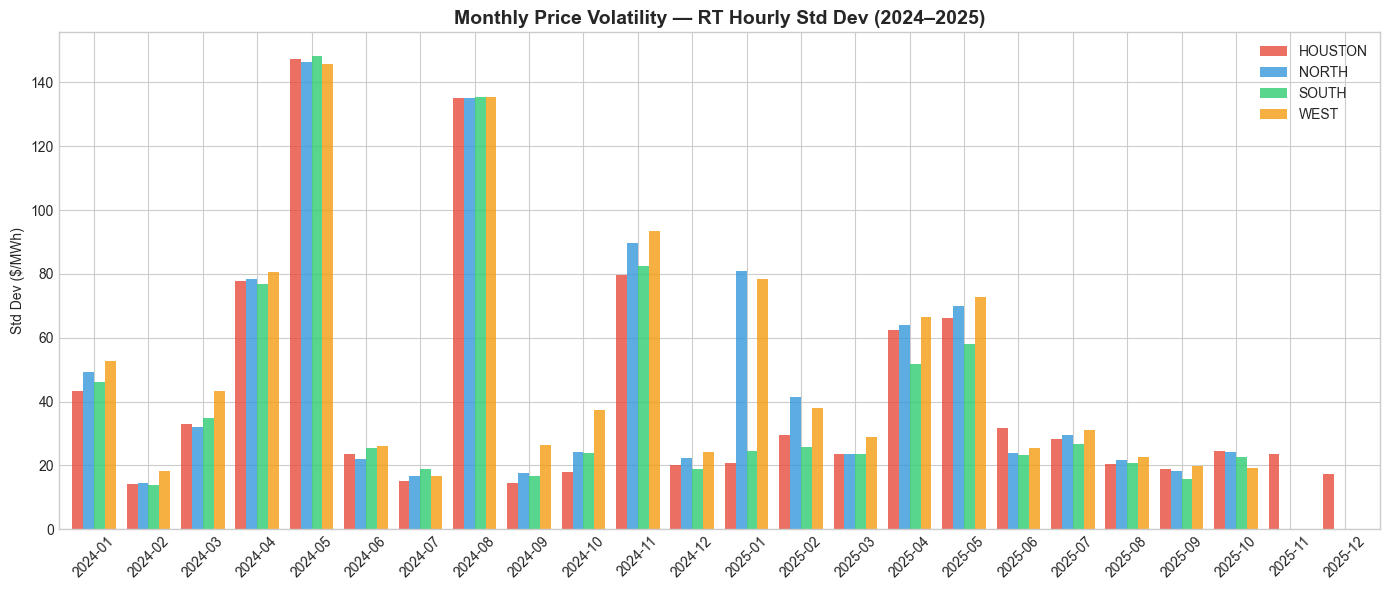

In [4]:
monthly_vol = rt_recent.resample('ME').std()
monthly_vol.index = monthly_vol.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, 6))
monthly_vol.plot(kind='bar', ax=ax, color=colors, alpha=0.8, width=0.8)
ax.set_title('Monthly Price Volatility — RT Hourly Std Dev (2024–2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Std Dev ($/MWh)')
ax.set_xlabel('')
ax.legend([h.replace('HB_', '') for h in HUBS])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Price Duration Curves

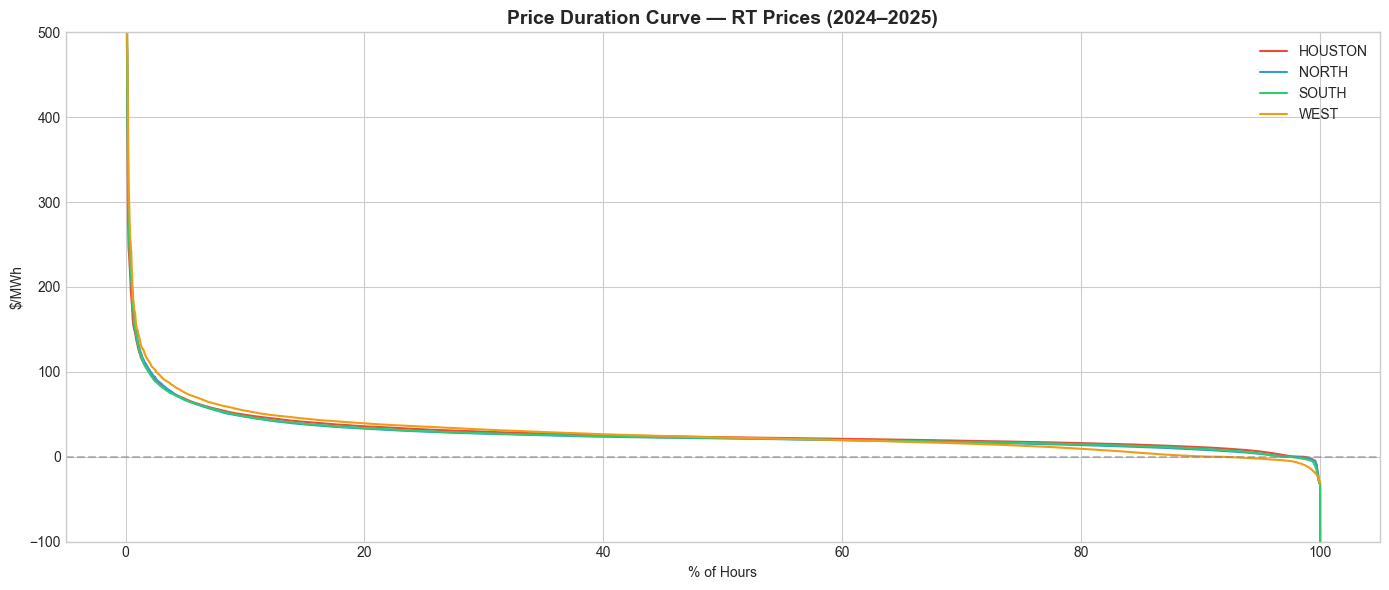

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
for hub, color in zip(HUBS, colors):
    sorted_prices = rt_recent[hub].dropna().sort_values(ascending=False).values
    pct = np.linspace(0, 100, len(sorted_prices))
    ax.plot(pct, sorted_prices, color=color, label=hub.replace('HB_', ''), linewidth=1.5)

ax.set_title('Price Duration Curve — RT Prices (2024–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('% of Hours')
ax.set_ylabel('$/MWh')
ax.set_ylim(-100, 500)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## Negative Price Frequency

In [6]:
neg_summary_rows = []
for hub in HUBS:
    prices = rt_recent[hub].dropna()
    neg_mask = prices < 0
    neg_summary_rows.append({
        'Hub': hub.replace('HB_', ''),
        'Negative Hours': neg_mask.sum(),
        '% of Hours': (neg_mask.sum() / len(prices) * 100),
        'Avg Negative Price ($/MWh)': prices[neg_mask].mean() if neg_mask.any() else 0,
        'Min Price ($/MWh)': prices.min(),
    })

neg_summary = pd.DataFrame(neg_summary_rows).set_index('Hub')
neg_summary.round(2)

,Negative Hours,% of Hours,Avg Negative Price ($/MWh),Min Price ($/MWh)
Hub,,,,
HOUSTON,277,1.58,-7.05,-163.63
NORTH,380,2.40,-4.90,-32.42
SOUTH,419,2.68,-6.04,-100.90
WEST,1357,8.71,-5.04,-31.74


## Daily Spread Analysis (Arbitrage Opportunity Sizing)

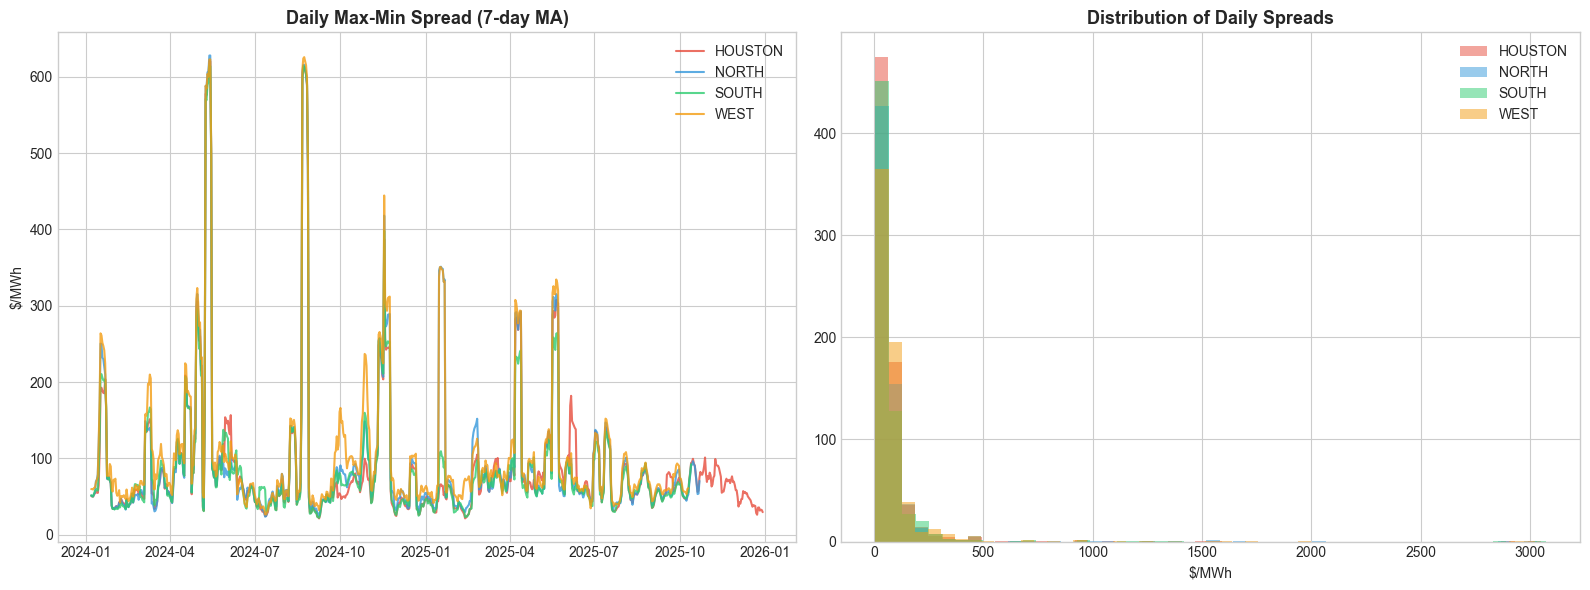

Daily Spread Summary ($/MWh):


,Mean Spread,Median Spread,Max Spread
HOUSTON,87.1,49.9,3051.8
NORTH,95.4,51.4,3034.0
SOUTH,89.1,49.8,3074.9
WEST,106.6,60.2,3024.3


In [7]:
# Daily max-min spread = theoretical max single-cycle arbitrage value
daily_spread = rt_recent.resample('D').max() - rt_recent.resample('D').min()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time series of daily spread
for hub, color in zip(HUBS, colors):
    axes[0].plot(daily_spread.index, daily_spread[hub].rolling(7).mean(), 
                 color=color, label=hub.replace('HB_', ''), alpha=0.8)
axes[0].set_title('Daily Max-Min Spread (7-day MA)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('$/MWh')
axes[0].legend()

# Distribution of daily spreads
for hub, color in zip(HUBS, colors):
    axes[1].hist(daily_spread[hub].dropna(), bins=50, alpha=0.5, color=color, 
                 label=hub.replace('HB_', ''))
axes[1].set_title('Distribution of Daily Spreads', fontsize=13, fontweight='bold')
axes[1].set_xlabel('$/MWh')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary stats
spread_stats = daily_spread.describe().T[['mean', '50%', 'max']].round(1)
spread_stats.columns = ['Mean Spread', 'Median Spread', 'Max Spread']
spread_stats.index = [h.replace('HB_', '') for h in HUBS]
print("Daily Spread Summary ($/MWh):")
spread_stats

## DA vs RT Spread

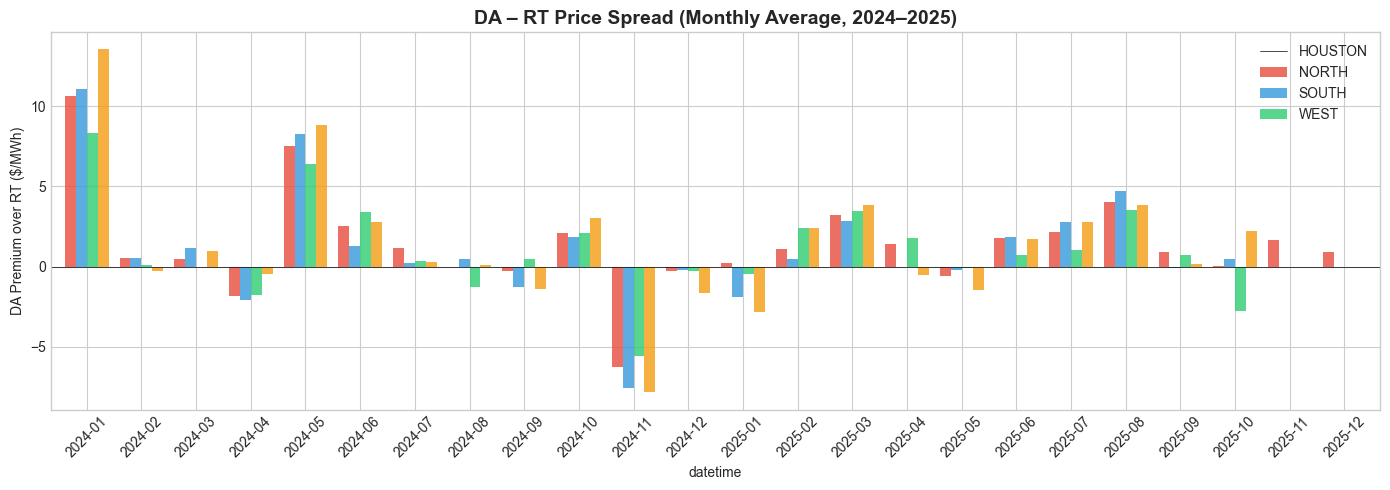


Overall DA-RT spread (2024-2025):
  HOUSTON: $+1.40/MWh (DA premium)
  NORTH: $+1.15/MWh (DA premium)
  SOUTH: $+1.13/MWh (DA premium)
  WEST: $+1.35/MWh (DA premium)


In [8]:
# Align DA and RT on common index
common_idx = rt_recent.index.intersection(da_recent.index)
rt_aligned = rt_recent.loc[common_idx]
da_aligned = da_recent.loc[common_idx]
da_rt_spread = da_aligned - rt_aligned

fig, ax = plt.subplots(figsize=(14, 5))
monthly_spread = da_rt_spread.resample('ME').mean()
monthly_spread.plot(kind='bar', ax=ax, color=colors, alpha=0.8, width=0.8)
ax.set_title('DA – RT Price Spread (Monthly Average, 2024–2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('DA Premium over RT ($/MWh)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend([h.replace('HB_', '') for h in HUBS])
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_spread.index], rotation=45)
plt.tight_layout()
plt.show()

print(f"\nOverall DA-RT spread (2024-2025):")
for hub in HUBS:
    spread = da_rt_spread[hub].mean()
    print(f"  {hub.replace('HB_', '')}: ${spread:+.2f}/MWh ({'DA premium' if spread > 0 else 'RT premium'})")

## Hub-Level Takeaways

Price analysis reveals strong arbitrage opportunity:
- **High volatility** especially summer months — wide daily spreads
- **Negative prices** occur regularly (wind/solar oversupply) — free charging for BESS
- **Hub differentiation** — West tends to be most volatile (wind-heavy region)
- **DA vs RT spread** — varying premium/discount creates additional arbitrage dimensions

---

## Nodal Price Analysis & Basis Risk

Now we go deeper: comparing **resource node prices** at 6 real ERCOT sites to their hub (HB_WEST). This reveals basis risk — the gap between hub-level revenue assumptions and actual nodal revenue.

In [9]:
SITES = {
    'Lamesa Solar':      'LAMESASLR_G',
    'Misae Solar':       'MISAE_GEN_RN',
    'Longhorn Wind':     'LHORN_N_U1_2',
    'Panther Creek':     'PC_NORTH_1',
    'Spinning Spur III': 'SSPURT_WIND1',
    'Stanton Wind':      'SWEC_G1',
}

# Load node RT prices
node_prices = {}
for label, node in SITES.items():
    path = os.path.join(PRICES_DIR, f'{node}_rt_hourly.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        node_prices[label] = df['price']
    else:
        print(f"Missing: {path}")

node_df = pd.DataFrame(node_prices)
node_recent = node_df['2024':'2025']

# Hub reference
hub_west = rt_recent['HB_WEST']

print(f"Loaded {len(node_prices)} node price series")
print(f"HB_WEST: {len(hub_west)} hours, Nodes: {node_recent.shape}")

Missing: ../data/prices/SSPURT_WIND1_rt_hourly.parquet
Loaded 5 node price series
HB_WEST: 17479 hours, Nodes: (17083, 5)


### Basis Differential: Node – Hub Price

In [10]:
# Compute basis = node_price - hub_price (aligned on common index)
common_idx = node_recent.index.intersection(hub_west.index)
basis_df = node_recent.loc[common_idx].subtract(hub_west.loc[common_idx], axis=0)

# Summary table
basis_summary = pd.DataFrame({
    'Mean Basis ($/MWh)': basis_df.mean(),
    'Std Dev': basis_df.std(),
    'P5': basis_df.quantile(0.05),
    'P95': basis_df.quantile(0.95),
    '% Hours Node < Hub': (basis_df < 0).mean() * 100,
    '% Hours Node > Hub': (basis_df > 0).mean() * 100,
}).round(2)
basis_summary

,Mean Basis ($/MWh),Std Dev,P5,P95,% Hours Node < Hub,% Hours Node > Hub
Lamesa Solar,8.95,41.24,-2.76,65.53,25.86,55.18
Misae Solar,-7.42,15.08,-35.67,1.62,61.61,20.86
Longhorn Wind,-8.00,16.47,-39.69,1.34,61.86,20.48
Panther Creek,1.18,20.54,-20.37,18.01,38.53,43.15
Stanton Wind,10.45,25.21,-1.23,56.29,23.29,58.57


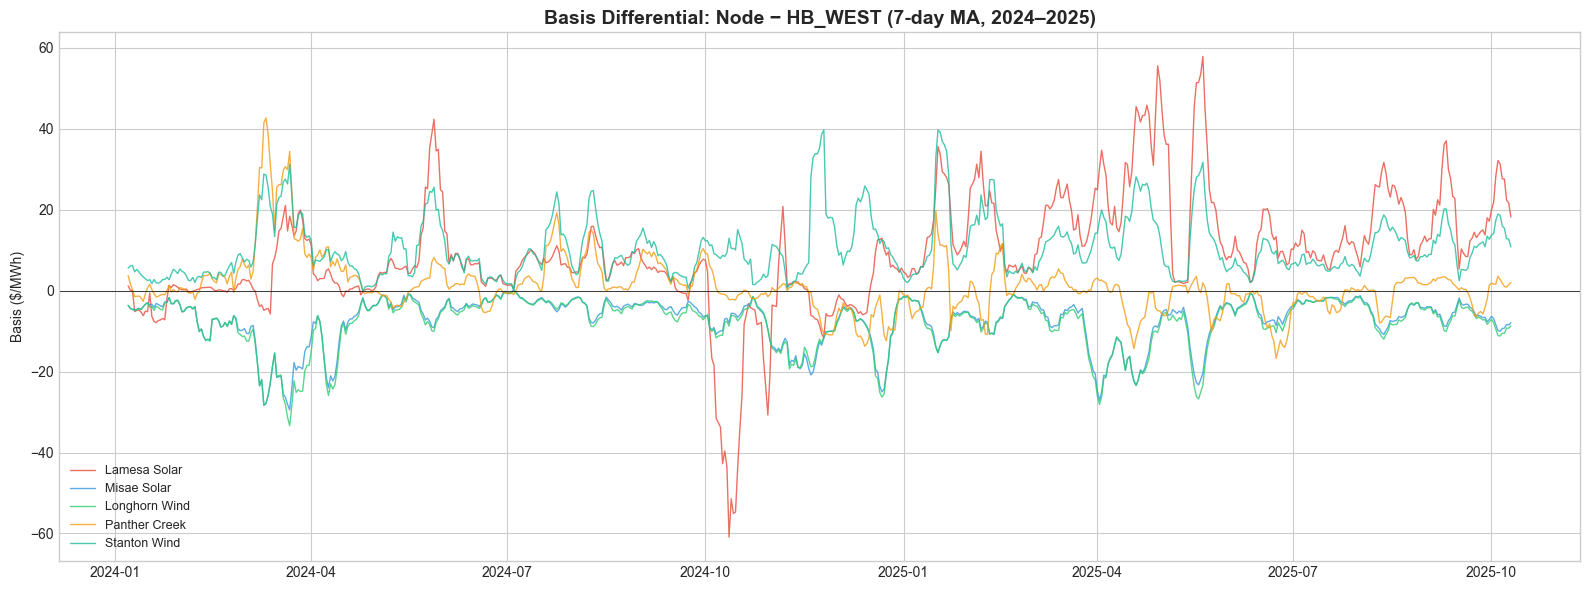

In [11]:
# Basis time series (daily average)
fig, ax = plt.subplots(figsize=(16, 6))
daily_basis = basis_df.resample('D').mean()
node_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (label, _), color in zip(SITES.items(), node_colors):
    if label in daily_basis.columns:
        ax.plot(daily_basis.index, daily_basis[label].rolling(7).mean(), 
                color=color, label=label, alpha=0.8, linewidth=1)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Basis Differential: Node − HB_WEST (7-day MA, 2024–2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Basis ($/MWh)')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

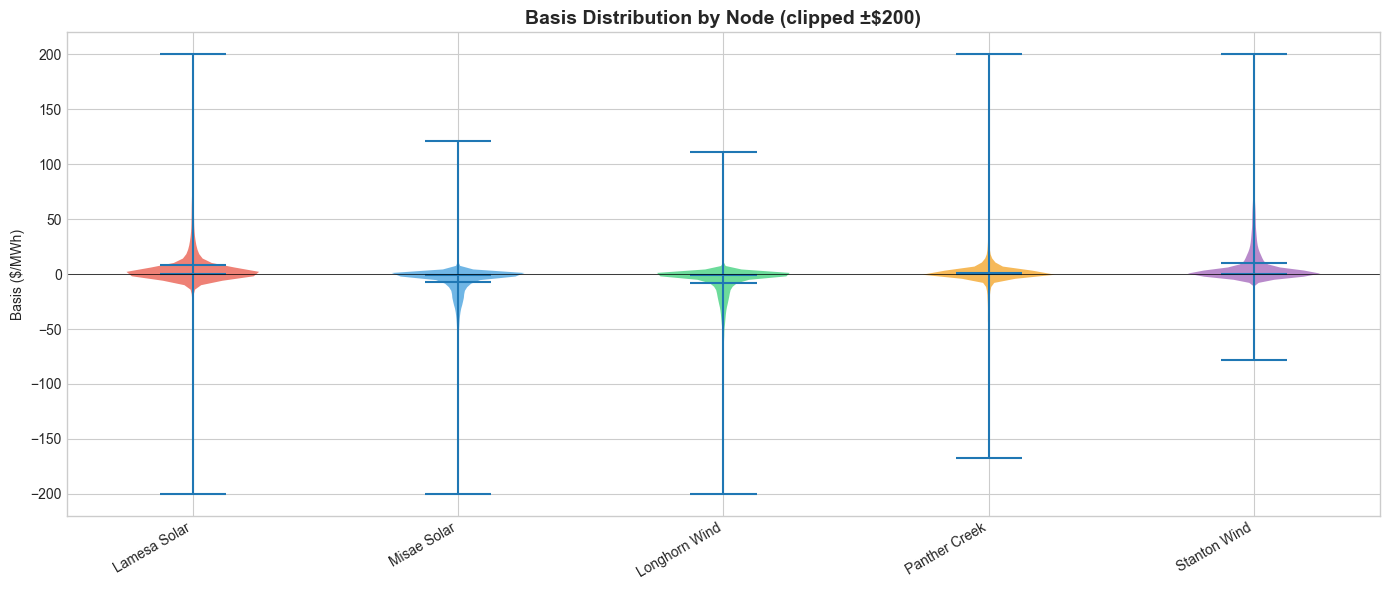

In [12]:
# Basis distribution (violin plot)
fig, ax = plt.subplots(figsize=(14, 6))
basis_data = [basis_df[col].dropna().clip(-200, 200).values for col in basis_df.columns]
parts = ax.violinplot(basis_data, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(node_colors[i])
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(basis_df.columns) + 1))
ax.set_xticklabels(basis_df.columns, rotation=30, ha='right')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Basis ($/MWh)')
ax.set_title('Basis Distribution by Node (clipped ±$200)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Basis Risk Insight

**Negative basis** means the node price is lower than the hub — common at wind/solar-heavy West Texas nodes due to **transmission congestion**. A co-located BESS would face this penalty: charging costs are similar (low prices everywhere) but discharge revenue is lower at the node than the hub.

This is the critical insight that hub-only BESS analyses miss. **NB 04 quantifies the revenue impact.**